In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import timm  # For MobileNet V1
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
import os

# Set device (use GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
# Data transforms (MobileNet V1 uses 224x224 input)
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load full dataset (change path)
dataset_path = '/home/rifat-cou/Documents/Project/Dataset_Raw'  # Folder with class subfolders
full_dataset = datasets.ImageFolder(dataset_path, transform=train_transform)

# Split into train/val (80/20)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Apply val transform to val set (no augmentation)
val_dataset.dataset.transform = val_transform

# Data loaders (batch 32 fits 6GB VRAM; ~2GB usage, increase to 64 if possible)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

# Class names
class_names = full_dataset.classes
print(f"Classes: {class_names}")
print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")

Classes: ['Chikenpox', 'Cowpox', 'Measles', 'MonkeyPox', 'Normal']
Train samples: 2088, Val samples: 523


In [3]:
# Load pre-trained MobileNet V1 from timm
model = timm.create_model('mobilenetv1_100', pretrained=True, num_classes=5)

# Freeze all layers except classifier (transfer learning)
model.requires_grad_(False)
model.classifier.requires_grad_(True)  # Unfreeze the final Linear layer

# Move to GPU
model = model.to(device)

# Print model summary (optional)
print(model)

model.safetensors:   0%|          | 0.00/17.0M [00:00<?, ?B/s]

EfficientNet(
  (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): ReLU6(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (bn1): BatchNormAct2d(
          32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): ReLU6(inplace=True)
        )
        (aa): Identity()
        (se): Identity()
        (conv_pw): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2): BatchNormAct2d(
          64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): ReLU6(inplace=True)
        )
        (drop_path): Identity()
      )
    )
    (1)

In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)  # Only train classifier first
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

Epoch 1/100 - Train Loss: 3.5645, Train Acc: 0.3008 | Val Loss: 3.0576, Val Acc: 0.4073
Epoch 2/100 - Train Loss: 2.5049, Train Acc: 0.4339 | Val Loss: 2.4478, Val Acc: 0.4665
Epoch 3/100 - Train Loss: 2.0323, Train Acc: 0.5134 | Val Loss: 2.0647, Val Acc: 0.5430
Epoch 4/100 - Train Loss: 1.7899, Train Acc: 0.5651 | Val Loss: 1.8376, Val Acc: 0.5966
Epoch 5/100 - Train Loss: 1.5042, Train Acc: 0.6197 | Val Loss: 1.6667, Val Acc: 0.6233
Epoch 6/100 - Train Loss: 1.2887, Train Acc: 0.6619 | Val Loss: 1.5809, Val Acc: 0.6310
Epoch 7/100 - Train Loss: 1.2304, Train Acc: 0.6662 | Val Loss: 1.4821, Val Acc: 0.6463
Epoch 8/100 - Train Loss: 1.1568, Train Acc: 0.6767 | Val Loss: 1.3946, Val Acc: 0.6673
Epoch 9/100 - Train Loss: 1.0635, Train Acc: 0.7040 | Val Loss: 1.3175, Val Acc: 0.6922
Epoch 10/100 - Train Loss: 0.9923, Train Acc: 0.7222 | Val Loss: 1.3132, Val Acc: 0.6807
Epoch 11/100 - Train Loss: 0.9401, Train Acc: 0.7294 | Val Loss: 1.2617, Val Acc: 0.6826
Epoch 12/100 - Train Loss: 0.8

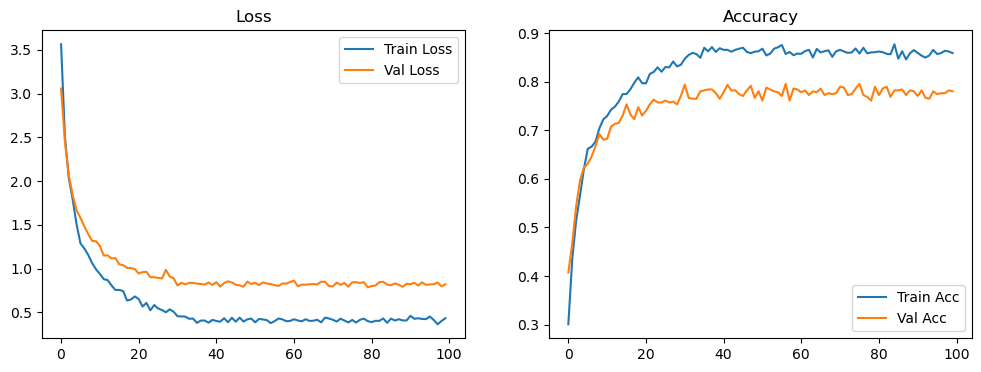

In [5]:
num_epochs = 100
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    # Train
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # Validate
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_loss /= len(val_loader)
    val_acc = correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    scheduler.step(val_loss)  # Adjust LR
    
    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

# Plot learning curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title('Loss')
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.legend()
plt.title('Accuracy')
plt.show()

In [7]:
# Predictions and report
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))
print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")

model_path = '/home/rifat-cou/Documents/Project/Models'
MobileNet = os.path.join(model_path, 'MobileNet_V1')
os.makedirs(MobileNet, exist_ok=True) 
# Save
torch.save(model.state_dict(), os.path.join(MobileNet, 'mobilenet_v1_100_skin_lesion.pth'))

              precision    recall  f1-score   support

   Chikenpox       0.64      0.73      0.69        94
      Cowpox       0.87      0.83      0.85        96
     Measles       0.91      0.84      0.87       106
   MonkeyPox       0.69      0.66      0.68       119
      Normal       0.81      0.84      0.83       108

    accuracy                           0.78       523
   macro avg       0.79      0.78      0.78       523
weighted avg       0.79      0.78      0.78       523

Accuracy: 0.7801
